In [1]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(display="diagram")
# import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.compose import ColumnTransformer

# Import necessary libraries
from sklearn.impute import SimpleImputer    
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# import k-nearest neighbors
from sklearn.neighbors import KNeighborsClassifier

# import decision tree classifier
from sklearn.tree import DecisionTreeClassifier

# import random forest classifier
from sklearn.ensemble import RandomForestClassifier
# import gradient boosting classifier
from sklearn.ensemble import GradientBoostingClassifier
# import support vector classifier
from sklearn.svm import SVC


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### **Predicting Dieabetes from survey data with ML classifiers**  
This notebook willexplore the use of ML models to predict diabates. I will use a dataset from the Diabetes Health Indicators Dataset at Kaggle provided by Alex Teboul. It is based on the The Behavioral Risk Factor Surveillance System (BRFSS), which is a health-related telephone survey that is collected annually by the CDC.     

# **Business understanding**

The business goal is to find a model that can predict the risk of diabetes from the survey data. If so, which of the factors in the dataset can explain the risk of diabetes? I will do EDA to understand the data and build initial baseline models with different ML classifiers (e.g. logistic regression,RandomForest) to find the best one for this task. Then I'll explore different ML algorithms to find one that does the best job of predicting which patient is likely to have diabetes.

# **Data Understanding**

In this section I will explore the Diabetes dataset to understand the fpllowing aspects:

* **Data types:** how many variables are there? What data types? Are there only numeric variables or also categorigal ones?  
* **data quality:** How many missing values are there? How many variables have a single value for all rows?
* **Correlations:** Which variables are correlated with each other or with price?
* **Data distributions:** What is the distribution of the variables? Which of them are skewed?
* **Outliers:** Are there aany outliers in the dataset? If so, how do we handle them?





In [2]:
# df = pd.read_csv('data/bank-additional-full.csv')

# Try reading the file with on_bad_lines='skip' to skip problematic lines
df = pd.read_csv('data/diabetes_binary_health_indicators_BRFSS2015.csv', on_bad_lines='skip')

In [3]:
df.shape

(253680, 22)

In [4]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
# show missing variables
df.isna().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [7]:
df = df.dropna()
df.shape



(253680, 22)

In [8]:
# Find out if any variable has the same value for all rows
df.nunique()


Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

In [9]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Show distributions

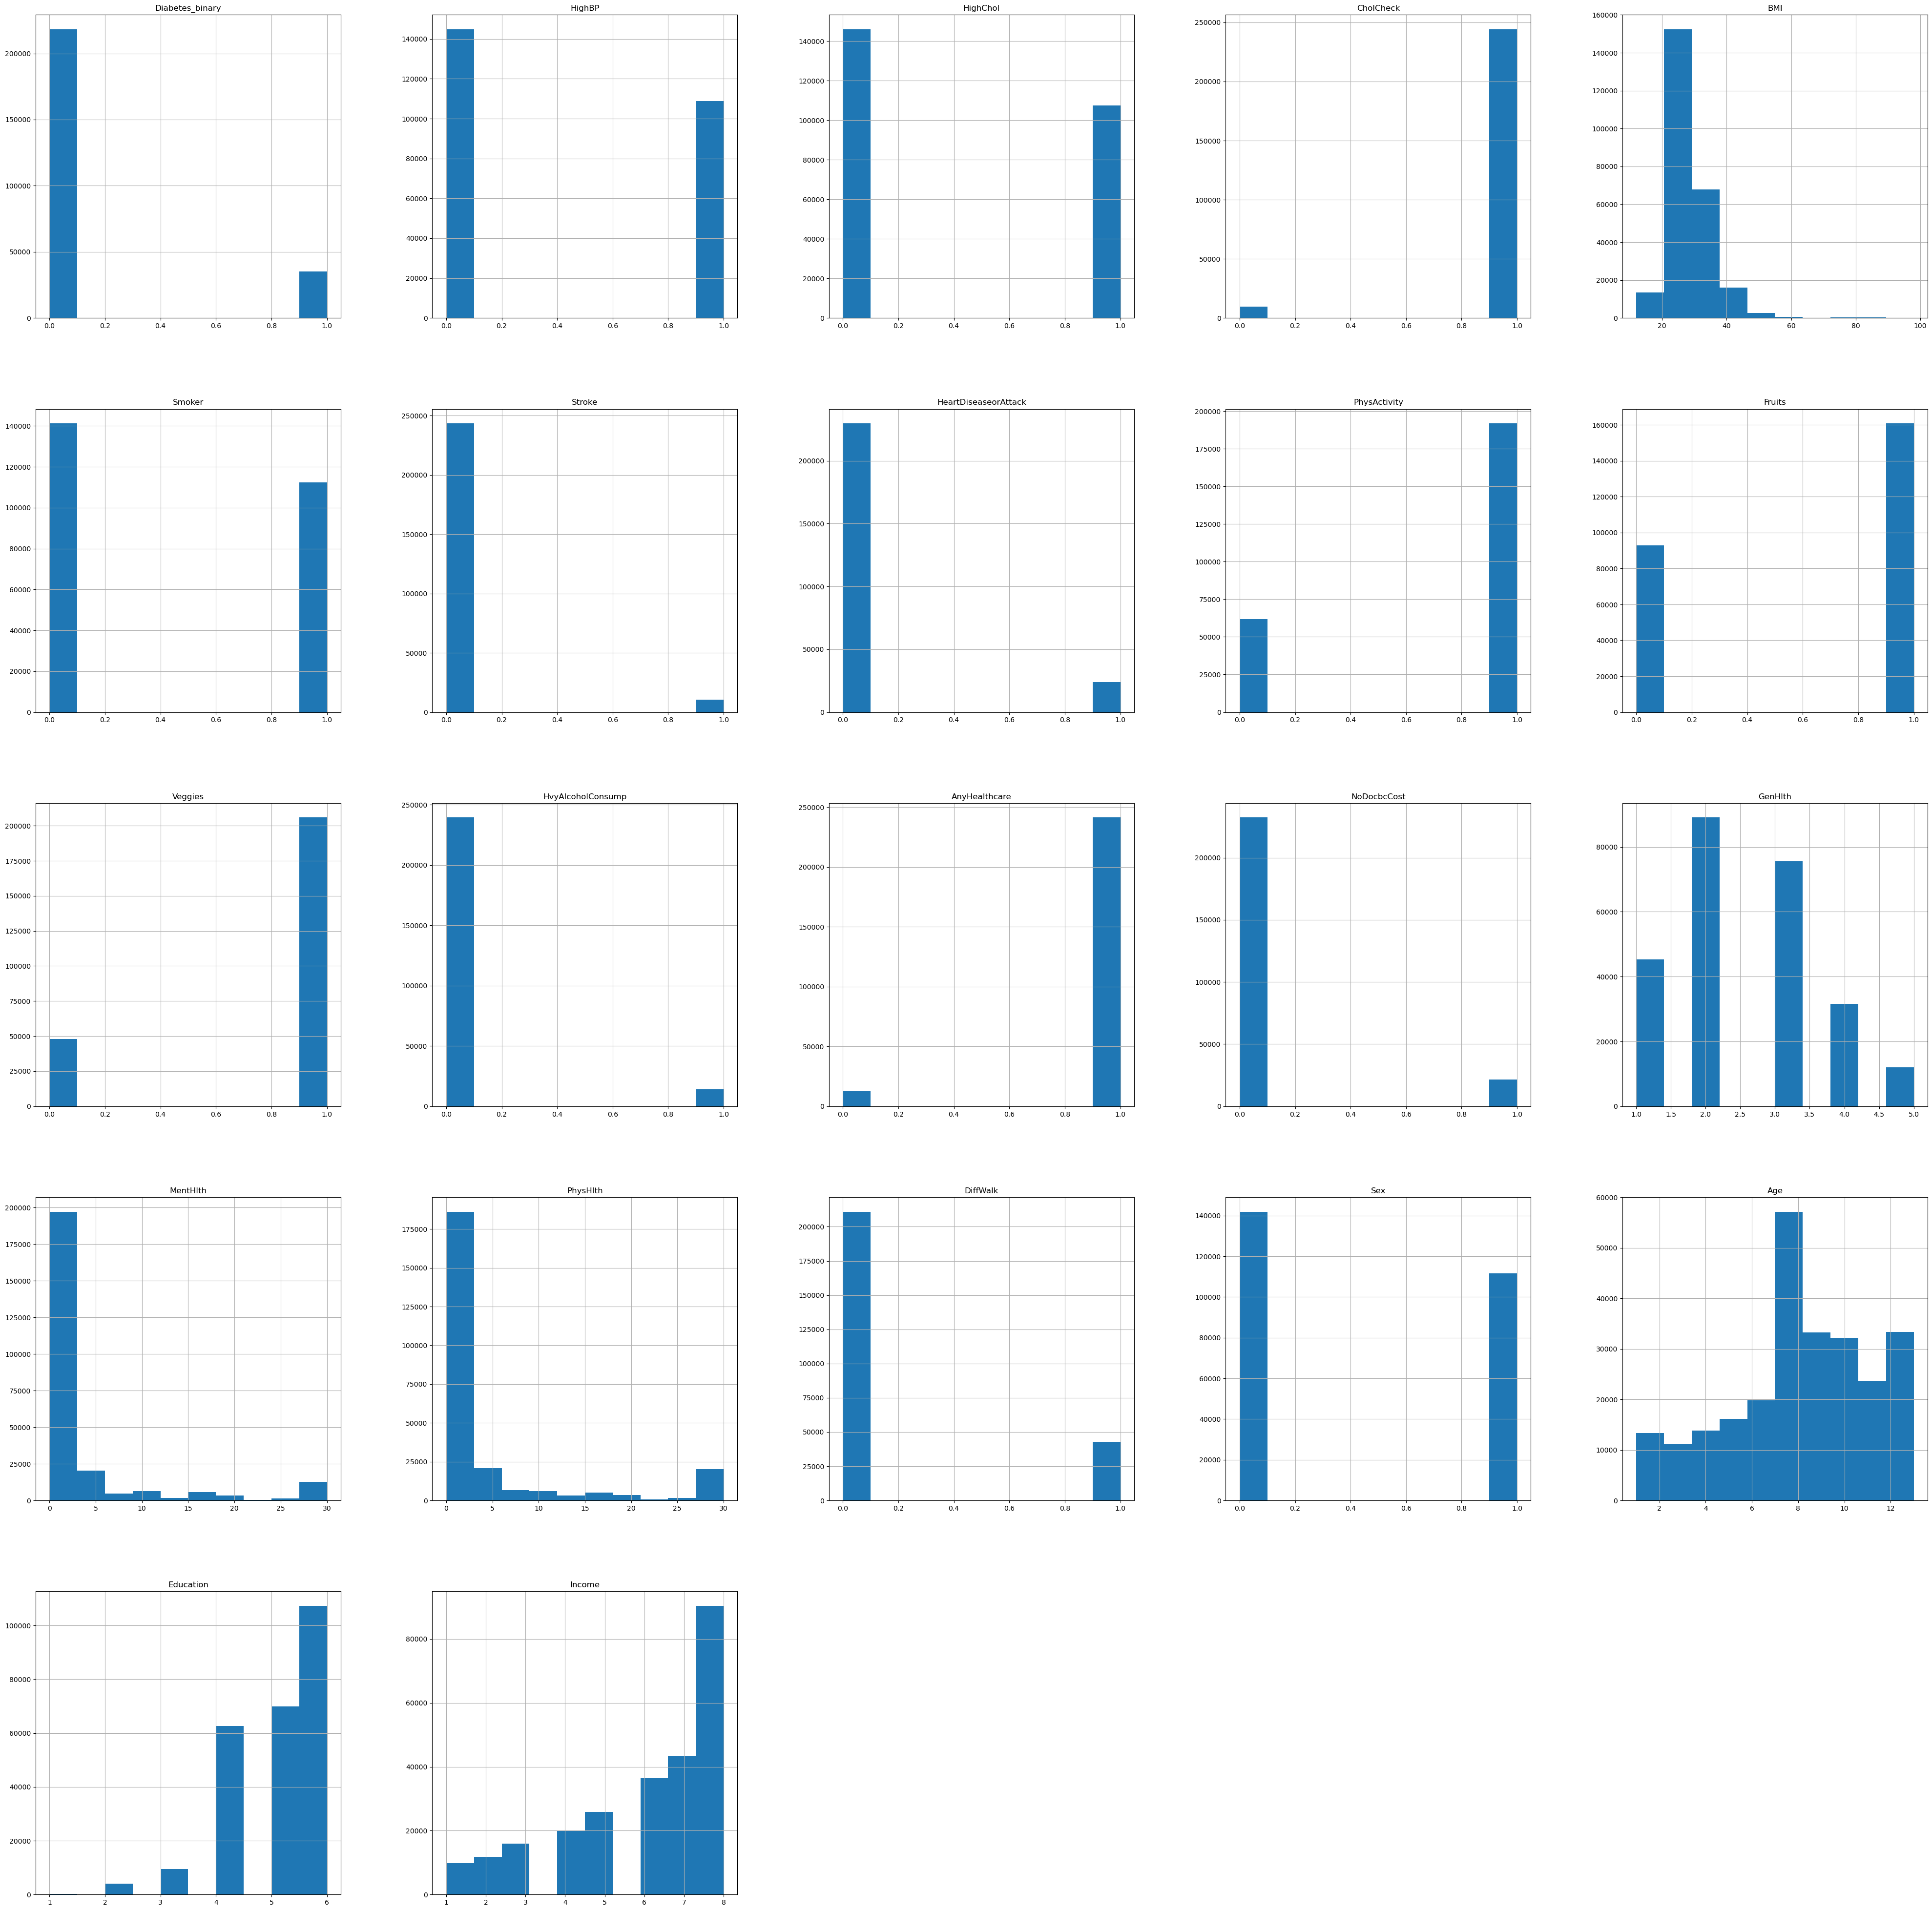

In [10]:
df.hist(figsize=(50, 50))
plt.show()

In [11]:
# show the rate of diabetes in the dataset
diabetes_rate = df['Diabetes_binary'].value_counts(normalize=True)
print("Rate of Diabetes:")
for k, v in diabetes_rate.items():
	print(f"{k}: {v:.2f}")

Rate of Diabetes:
0.0: 0.86
1.0: 0.14



***This dataset is imbalanced, with 86% of non-diabetic cases compared to only 13.9% of diabetic cases. 
This class imbalance should be considered when building and evaluating predictive models***.



In [12]:
# Show the percentages of people in each bucket of cholesterol
cholesterol_counts = df['HighChol'].value_counts(normalize=True)
print("\nCholesterol Levels:")
for k, v in cholesterol_counts.items():
	print(f"{k}: {v:.2f}")


Cholesterol Levels:
0.0: 0.58
1.0: 0.42


In [13]:
# Show the percentages of people in each bucket of BMI
bmi_counts = df['BMI'].value_counts(bins=10, normalize=True).sort_index()
print("\nBMI Distribution:")    

for k, v in bmi_counts.items():
	print(f"{k}: {v:.2f}")


BMI Distribution:
(11.913, 20.6]: 0.05
(20.6, 29.2]: 0.60
(29.2, 37.8]: 0.27
(37.8, 46.4]: 0.06
(46.4, 55.0]: 0.01
(55.0, 63.6]: 0.00
(63.6, 72.2]: 0.00
(72.2, 80.8]: 0.00
(80.8, 89.4]: 0.00
(89.4, 98.0]: 0.00


In [14]:
# Show the percentages of people in each bucket of stroke
stroke_counts = df['Stroke'].value_counts(normalize=True)
print("\nStroke History:")
for k, v in stroke_counts.items():
    print(f"{k}: {v:.2f}")


Stroke History:
0.0: 0.96
1.0: 0.04


In [15]:
# Show the percentages of people in each bucket of health coverage
hlthcov_counts = df['AnyHealthcare'].value_counts(normalize=True)
print("\nHealth coverage:")
for k, v in hlthcov_counts.items():
    print(f"{k}: {v:.2f}")


Health coverage:
1.0: 0.95
0.0: 0.05


In [16]:
# Show the percentages of people in each bucket of NoDocbcCost
doc_access_counts = df['NoDocbcCost'].value_counts(normalize=True)
print("\nAccess to Doctor:")
for k, v in doc_access_counts.items():
    print(f"{k}: {v:.2f}")


Access to Doctor:
0.0: 0.92
1.0: 0.08


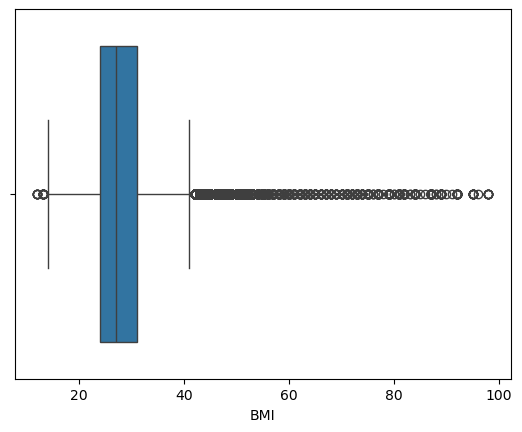

In [17]:
# Search for outliers in BMI using boxplot
sns.boxplot(x=df['BMI'])
plt.show()

***BMI clearly has many outliers with very high BMI values!***

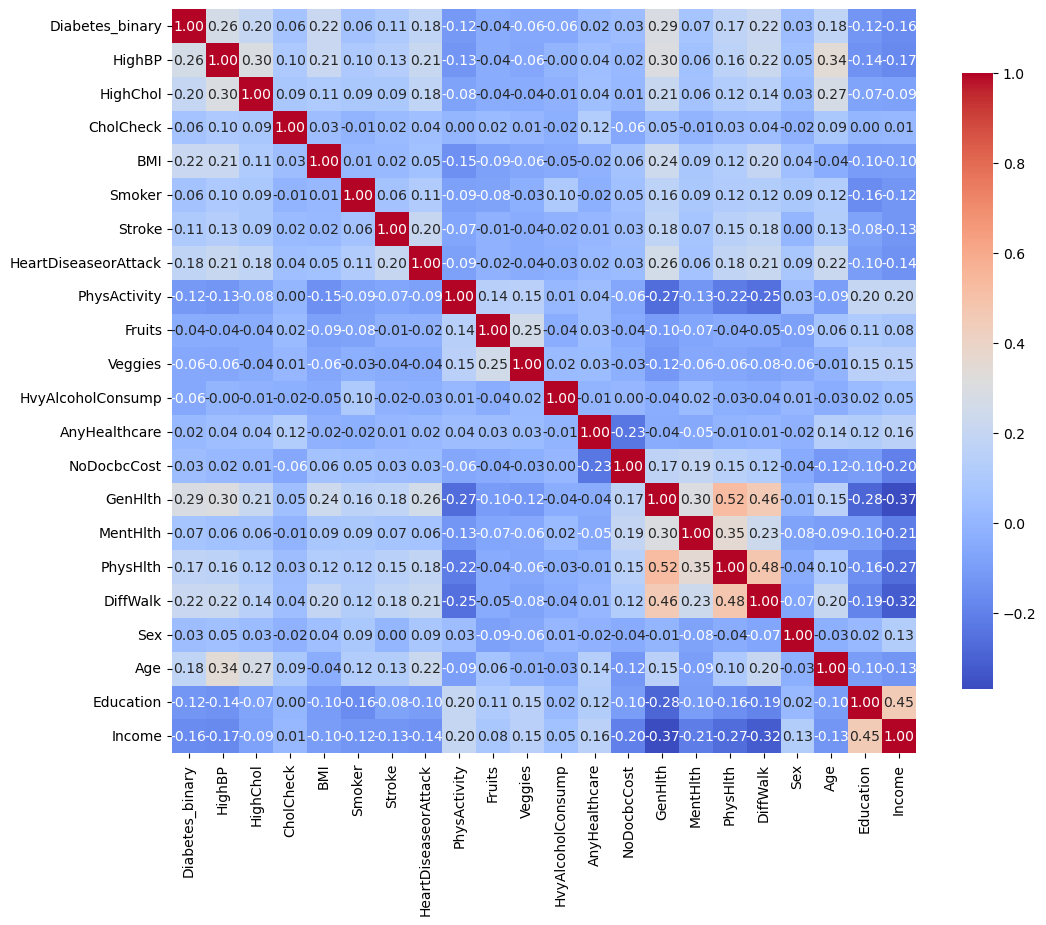

In [18]:
# Find correlation matrix
corr = df.corr()

# Display the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))    
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.show()



# **Data Preparation**

In [19]:
# Correct the class imbalance using SMOTE
from imblearn.over_sampling import SMOTE
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
X_res.shape, y_res.shape

((436668, 21), (436668,))

In [20]:
# Now show the new rate of diabetes
new_diabetes_rate = pd.Series(y_res).value_counts(normalize=True)
print("New Rate of Diabetes after SMOTE:")
print(new_diabetes_rate)

New Rate of Diabetes after SMOTE:
Diabetes_binary
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


***The dataset is now balanced with 50% of patients with diabetes and 50% with no diabetes!***

In [21]:
# Split the data into X_train, X_test, y_train and y_test
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)


In [22]:
X_train.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
338110,1.0,0.683286,1.0,38.000000,0.683286,0.0,0.0,1.0,1.0,0.683286,...,1.0,0.0,4.683286,14.683286,14.683286,1.0,0.683286,8.683286,5.000000,6.0
314646,1.0,1.000000,1.0,24.092458,0.000000,0.0,0.0,1.0,1.0,1.000000,...,1.0,0.0,3.000000,0.092458,1.907542,0.0,0.000000,9.000000,5.907542,7.0
3626,0.0,0.000000,1.0,36.000000,0.000000,0.0,0.0,1.0,1.0,1.000000,...,1.0,0.0,2.000000,3.000000,0.000000,0.0,0.000000,5.000000,6.000000,6.0
191870,0.0,0.000000,1.0,26.000000,0.000000,0.0,0.0,1.0,0.0,1.000000,...,1.0,0.0,2.000000,10.000000,5.000000,0.0,1.000000,3.000000,6.000000,5.0
299244,1.0,1.000000,1.0,26.308881,0.691119,0.0,0.0,1.0,1.0,1.000000,...,1.0,0.0,3.000000,0.000000,0.000000,0.0,0.000000,7.000000,6.000000,8.0


In [23]:
X_test.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4704,0.0,0.000000,1.0,24.000000,1.0,0.000000,0.0,1.0,1.0,1.000000,...,1.0,0.0,2.000000,0.0,2.0,0.0,1.0,8.000000,5.000000,7.0
96269,0.0,0.000000,1.0,25.000000,0.0,0.000000,0.0,1.0,0.0,1.000000,...,1.0,0.0,1.000000,20.0,0.0,0.0,1.0,6.000000,6.000000,8.0
328468,1.0,0.823902,1.0,37.528295,0.0,0.823902,1.0,0.0,0.0,0.823902,...,1.0,0.0,5.000000,30.0,17.0,1.0,0.0,9.176098,3.647803,1.0
25805,0.0,1.000000,1.0,28.000000,0.0,0.000000,0.0,1.0,0.0,1.000000,...,1.0,0.0,2.000000,5.0,0.0,0.0,0.0,5.000000,6.000000,7.0
319112,1.0,1.000000,1.0,35.000000,0.0,0.000000,0.0,1.0,1.0,1.000000,...,1.0,0.0,2.333251,0.0,0.0,0.0,1.0,9.000000,5.000000,8.0


In [24]:
# Create a ColumnTransformer to apply different transformations to different column types
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns
numerical_features = X_train.select_dtypes(include=np.number).columns

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)

In [25]:
# Create a pipepline that does the following: 1) Uses onehotencoder to encode categorical variables in df, scales numerical variables, then performs Logistic regression .
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, solver='saga', tol=0.1))
])

## **Baseline model with Logistic regression**

In [26]:
# Use GridSearch to build a model with the above pipeline, pipe
param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
}

lr_grid = GridSearchCV(pipe, param_grid, cv=5)
lr_grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", lr_grid.best_params_)
print("Best cross-validation score:", lr_grid.best_score_)

Best parameters: {'model__C': 0.1, 'model__penalty': 'l1'}
Best cross-validation score: 0.7562218391403912


In [27]:
# show best model and its coefficients
print(lr_grid.best_estimator_)
print(lr_grid.best_estimator_.named_steps['model'].coef_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object')),
                                                 ('scaler', StandardScaler(),
                                                  Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(C=0.1, max_iter=1000, penalty='l1',
                                    solver='saga', tol=0.1))])
[[ 0.43779032  0.31610399  0.26588371  0.48169784 -0.02197099 -0.00

[ 0.44  0.32  0.27  0.48 -0.02 -0.    0.04  0.   -0.    0.03 -0.22  0.04
 -0.06  0.74 -0.04 -0.07  0.04  0.16  0.41 -0.04 -0.11]


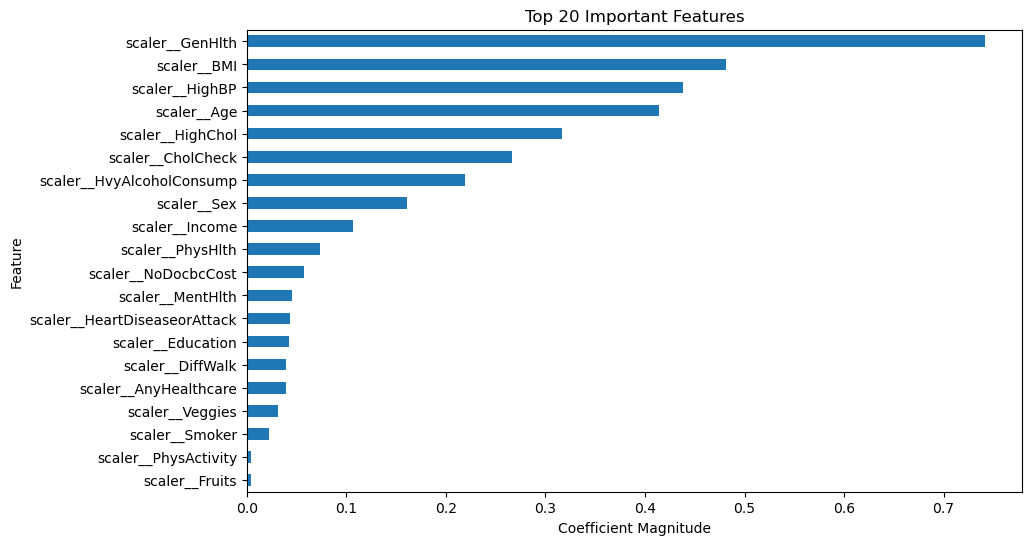

In [28]:
lr_best = lr_grid.best_estimator_
model = lr_best.named_steps['model']
pre = lr_best.named_steps['preprocessor']

coefs = model.coef_                 # shape (1, n_features)
feature_names = pre.get_feature_names_out()

importances = coefs.ravel()         # shape (n_features,)
important_features = pd.Series(importances, index=feature_names)

# Often you want magnitude:
important_features = important_features.abs().sort_values(ascending=False)
print(importances.round(2))
# Plot the important features
plt.figure(figsize=(10, 6))
important_features.head(20).plot(kind='barh')
plt.title('Top 20 Important Features')
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

In [29]:
important_features.head(10)

scaler__GenHlth              0.741575
scaler__BMI                  0.481698
scaler__HighBP               0.437790
scaler__Age                  0.413752
scaler__HighChol             0.316104
scaler__CholCheck            0.265884
scaler__HvyAlcoholConsump    0.218803
scaler__Sex                  0.161049
scaler__Income               0.106527
scaler__PhysHlth             0.073298
dtype: float64

## Performance metric for Logistic regression

F1: 0.76
Precision: 0.74
Recall: 0.79
AUC: 0.83
Accuracy: 0.75


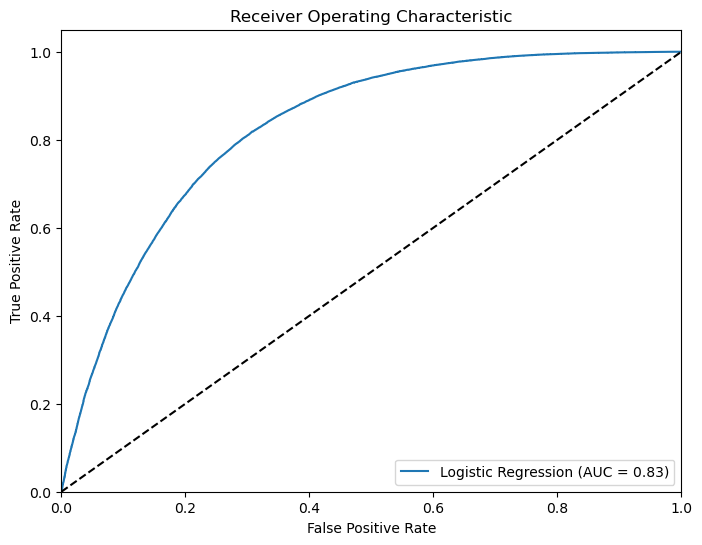

In [30]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

lr_best = lr_grid.best_estimator_
model = lr_best.named_steps['model']

# choose your positive class explicitly
positive = 1.0   # <- change if your "positive" is different

# Predictions
y_pred = lr_grid.predict(X_test)

# Find the column index in predict_proba corresponding to the positive class
pos_idx = np.where(model.classes_ == positive)[0][0]
y_score = lr_grid.predict_proba(X_test)[:, pos_idx]

# Metrics (explicitly set pos_label for binary string labels)
lr_f1 = f1_score(y_test, y_pred, pos_label=positive)
lr_precision = precision_score(y_test, y_pred, pos_label=positive)
lr_recall = recall_score(y_test, y_pred, pos_label=positive)
lr_auc = roc_auc_score(y_test, y_score)                    # y_score is prob of "positive"
lr_acc = accuracy_score(y_test, y_pred)

print("F1: %0.2f" % lr_f1)
print("Precision: %0.2f" % lr_precision)
print("Recall: %0.2f" % lr_recall)
print("AUC: %0.2f" % lr_auc)
print("Accuracy: %0.2f" % lr_acc)
# Plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % lr_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


***This is a big improvement in performance due to rebalancing the classes. Before applying SMOTE the Logistic regression model with imbalanced dataset only had an F1 score of only 0.25, precision of 0.55 and recall of 0.16.***

## **RandomForest model**

In [31]:
# Now build a pipeline that uses RandomForest classifier
rf_pipe = Pipeline([
    ('preprocessor2', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])


In [32]:
# Define the parameter grid
param_grid = {
    'model__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'model__max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'model__min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'model__min_samples_leaf': [1, 2, 4],    # Minimum samples required at a leaf node
    'model__bootstrap': [True, False]        # Whether bootstrap samples are used
}

rf_grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='accuracy', verbose=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best cross-validation score:", rf_grid.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Users\Valentine Fontama\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters: {'model__bootstrap': True, 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best cross-validation score: 0.920829351092085


F1: 0.92
Precision: 0.96
Recall: 0.88
AUC: 0.97
Accuracy: 0.92
Confusion matrix


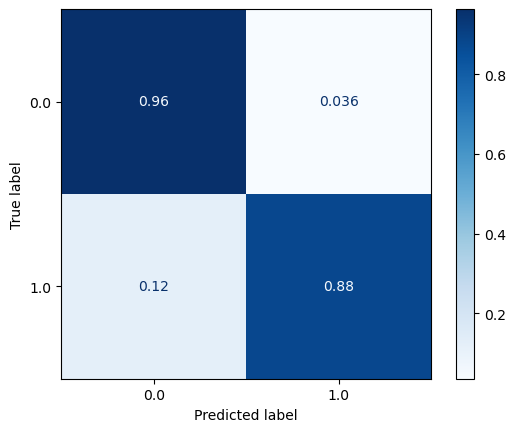

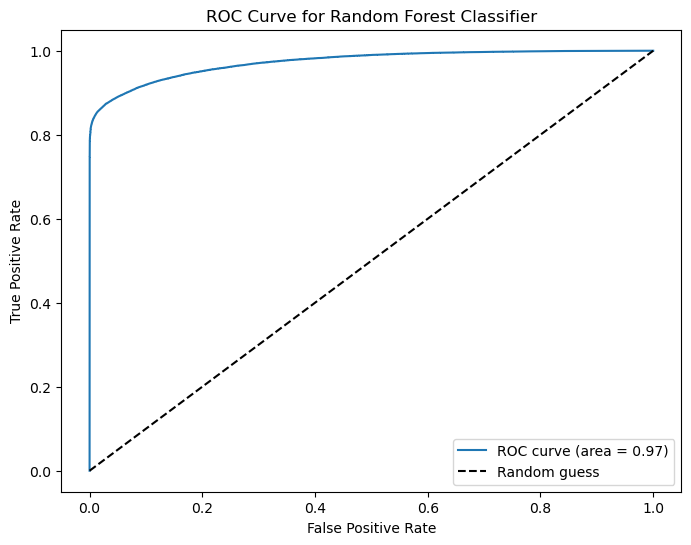

In [33]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

best_rf = rf_grid.best_estimator_
model = best_rf.named_steps['model']

# choose your positive class explicitly
positive = 1.0

# Predictions
y_pred = rf_grid.predict(X_test)

# Find the column index in predict_proba corresponding to the positive class
pos_idx = np.where(model.classes_ == positive)[0][0]
y_score = rf_grid.predict_proba(X_test)[:, pos_idx]

# Metrics (explicitly set pos_label for binary string labels)
rf_f1 = f1_score(y_test, y_pred, pos_label=positive)
rf_precision = precision_score(y_test, y_pred, pos_label=positive)
rf_recall = recall_score(y_test, y_pred, pos_label=positive)
rf_auc = roc_auc_score(y_test, y_score)                    # y_score is prob of "positive"
rf_acc = accuracy_score(y_test, y_pred)

print("F1: %0.2f" % rf_f1)
print("Precision: %0.2f" % (rf_precision))
print("Recall: %0.2f" % rf_recall)
print("AUC: %0.2f" % rf_auc)
print("Accuracy: %0.2f" % rf_acc)

# Show confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf_grid, X_test, y_test, display_labels=model.classes_,
                                        cmap=plt.cm.Blues, normalize='true')
print("Confusion matrix")
plt.show()

# Plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(rf_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Classifier')
plt.legend()
plt.show()

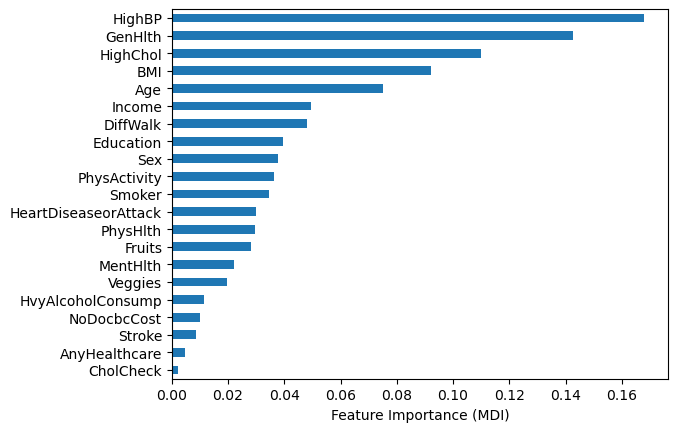

In [35]:
from sklearn.inspection import permutation_importance

results = permutation_importance(rf_grid.best_estimator_, X_test, y_test)

importances = rf_grid.best_estimator_.named_steps['model'].feature_importances_
feature_names = X_train.columns  # use the column names from your training data
forest_importances = pd.Series(importances, index=feature_names)

forest_importances.sort_values().plot.barh()
plt.xlabel("Feature Importance (MDI)")
plt.show()

## **XGBoost model**

In [42]:
# Install xgboost if not already installed
%pip install xgboost

from xgboost import XGBClassifier

# Now build a pipeline that uses XGBoost classifier
xgb_pipe = Pipeline([
    ('preprocessor2', preprocessor),
    ('model', XGBClassifier(random_state=42))
])


   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
    --------------------------------------- 1.3/56.8 MB 11.2 MB/s eta 0:00:05
   -- ------------------------------------- 4.2/56.8 MB 12.6 MB/s eta 0:00:05
   ----- ---------------------------------- 7.3/56.8 MB 15.1 MB/s eta 0:00:04
   ------- -------------------------------- 11.3/56.8 MB 15.0 MB/s eta 0:00:04
   -------- ------------------------------- 12.1/56.8 MB 13.0 MB/s eta 0:00:04
   ---------- ----------------------------- 15.2/56.8 MB 12.7 MB/s eta 0:00:04
   ------------ --------------------------- 18.4/56.8 MB 13.0 MB/s eta 0:00:03
   --------------- ------------------------ 21.8/56.8 MB 13.5 MB/s eta 0:00:03
   ----------------- ---------------------- 25.4/56.8 MB 14.1 MB/s eta 0:00:03
   -------------------- ------------------- 29.4/56.8 MB 14.4 MB/s eta 0:00:02
   ---------------------- ----------------- 32.2/56.8 MB 14.3 MB/s eta 0:00:02
   ------------------------- -------------- 36.2/56.8 MB 14.6 MB

In [43]:
# Define the parameter grid for XGBoost
param_grid = {
    'model__n_estimators': [100, 200, 300],  # Number of trees in the forest
    'model__learning_rate': [0.01, 0.1, 0.2],  # Learning rate
    'model__max_depth': [3, 6, 10],  # Maximum depth of the tree
    'model__colsample_bytree': [0.5, 0.7],  # Minimum samples required to split a node
    'model__min_child_weight': [1, 5, 10]        # Whether bootstrap samples are used
}

grid = GridSearchCV(xgb_pipe, param_grid, cv=5, scoring='accuracy', verbose=3, n_jobs=-1)
grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters: {'model__colsample_bytree': 0.5, 'model__learning_rate': 0.2, 'model__max_depth': 6, 'model__min_child_weight': 1, 'model__n_estimators': 200}
Best cross-validation score: 0.9190888992908945


F1: 0.91
Precision: 0.97
Recall: 0.86
AUC: 0.97
Accuracy: 0.92
Confusion matrix


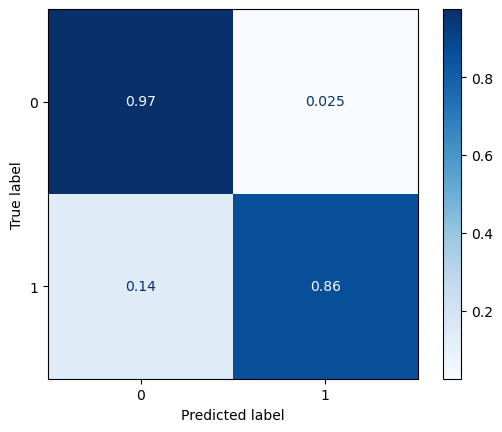

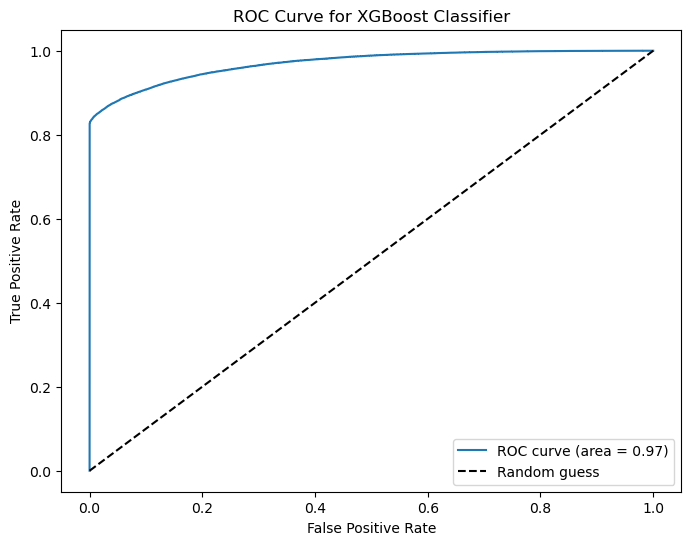

In [44]:
best = grid.best_estimator_
model = best.named_steps['model']

# choose your positive class explicitly
positive = 1.0

# Predictions
y_pred = grid.predict(X_test)

# Find the column index in predict_proba corresponding to the positive class
pos_idx = np.where(model.classes_ == positive)[0][0]
y_score = grid.predict_proba(X_test)[:, pos_idx]

# Metrics (explicitly set pos_label for binary string labels)
xgb_f1 = f1_score(y_test, y_pred, pos_label=positive)
xgb_precision = precision_score(y_test, y_pred, pos_label=positive)
xgb_recall = recall_score(y_test, y_pred, pos_label=positive)
xgb_auc = roc_auc_score(y_test, y_score)                    # y_score is prob of "positive"
xgb_acc = accuracy_score(y_test, y_pred)

print("F1: %0.2f" % xgb_f1)
print("Precision: %0.2f" % (xgb_precision))
print("Recall: %0.2f" % xgb_recall)
print("AUC: %0.2f" % xgb_auc)
print("Accuracy: %0.2f" % xgb_acc)

# Show confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(grid, X_test, y_test, display_labels=model.classes_,
                                        cmap=plt.cm.Blues, normalize='true')
print("Confusion matrix")
plt.show()

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(xgb_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost Classifier')
plt.legend()
plt.show()

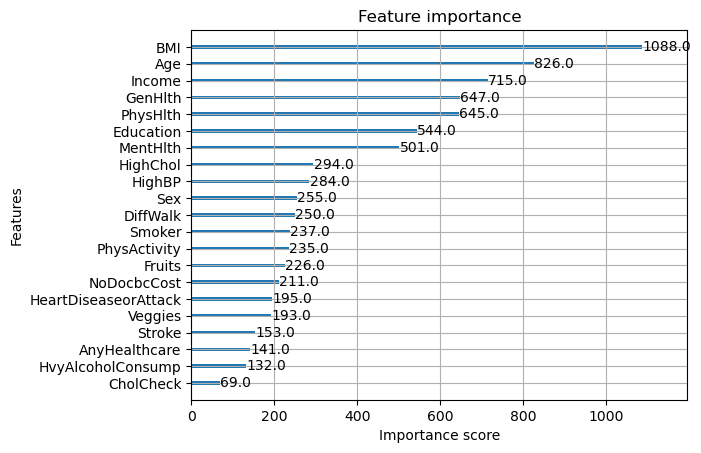

In [51]:
# Access the XGBoost model inside the pipeline and plot feature importance
import xgboost as xgb

feature_names = X_train.columns.tolist()

booster = grid.best_estimator_.named_steps['model'].get_booster()
booster.feature_names = feature_names

xgb.plot_importance(booster)
plt.show()

In [46]:
# Compare the performance of different models and show the results in a table like the below table
#                **Model F1 Score Precision    Recall       AUC  Accuracy
#        Random Forest  0.343662   0.675277  0.230479  0.804651  0.885372
#  Logistic Regression  0.331439   0.667939  0.220403  0.795218  0.884224

print("                **Model F1 Score Precision    Recall       AUC  Accuracy")
print("        Random Forest %0.2f   %0.2f  %0.2f  %0.2f  %0.2f" % (rf_f1, rf_precision, rf_recall, rf_auc, rf_acc))
print("              XGBoost %0.2f   %0.2f  %0.2f  %0.2f  %0.2f" % (xgb_f1, xgb_precision, xgb_recall, xgb_auc, xgb_acc))
print("  Logistic Regression %0.2f   %0.2f  %0.2f  %0.2f  %0.2f" % (lr_f1, lr_precision, lr_recall, lr_auc, lr_acc))




                **Model F1 Score Precision    Recall       AUC  Accuracy
        Random Forest 0.92   0.96  0.88  0.97  0.92
              XGBoost 0.91   0.97  0.86  0.97  0.92
  Logistic Regression 0.76   0.74  0.78  0.83  0.75
